In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm

from pydub import AudioSegment
from pydub.utils import make_chunks
from IPython.display import Audio
from scipy import signal

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
CHUNK_LENGTH = 3000 # pydub calculates in millisec

def convert_to_mono(audio):
    """Convert stereo audio to mono."""
    return audio.set_channels(1)

def get_split_unique(path, base_filename):
    """
    Splits an audio file into 1.5-second chunks and names each chunk uniquely.

    Args:
        path (str): The file path to the input audio file.
        base_filename (str): The base name to use for naming the chunk files.

    Returns:
        list: A list of in-memory audio chunks.
    """
    # Carga el archivo de audio
    try:
        audio = AudioSegment.from_file(path, "mp3")
    except Exception as e:
        print(f"Error al cargar el archivo de audio {path}: {e}")
        os.remove(path)
        return []
    
    mono_audio = convert_to_mono(audio)
    chunk_length_ms = CHUNK_LENGTH  
    chunks = make_chunks(mono_audio, chunk_length_ms)

    # Ensure that the chunks directory exists
    if not os.path.exists("chunks"):
        os.makedirs("chunks")

    paths = []
    for i, chunk in enumerate(tqdm(chunks, desc="Processing chunks")):
        chunk_name = f"chunks/{base_filename}_chunk{i}.mp3"  # Unique naming
        
        # Check if the chunk file already exists
        if not os.path.exists(chunk_name):
            chunk.export(chunk_name, format="mp3")
            paths.append(chunk_name)
        else:
            #print(f"Chunk {chunk_name} already exists, skipping.")
            paths.append(chunk_name)

    return paths

def get_split_with_label(row):
    """
    Splits an audio file into chunks and associates each chunk with the audio's original label.

    Args:
        row (pd.Series): A row from a DataFrame containing 'audio_path' and 'label'.

    Returns:
        list of tuples: A list of tuples, where each tuple contains the path to a chunk and the label.
    """
    path = row['audio_path']
    label = row['label']
    base_filename = os.path.splitext(os.path.basename(path))[0]
    chunk_paths = get_split_unique(path, base_filename)
    return [(chunk_path, label) for chunk_path in chunk_paths]

In [ ]:
df = pd.read_csv('./data/train_muestra.csv')
#df = pd.read_csv('./data/val_muestra.csv')
#df = pd.read_csv('./data/test_muestra.csv')
df = df[['audio_path', 'label']]
print(df.shape)
df.shape

In [4]:
#df = df[~df['audio_path'].str.contains(r'./songs\\Tyrannidae\\Megarynchus\\Megarynchus pitangua\\Boat-billedFlycatcher\\295771.mp3')]

In [5]:
chunk_data = df.apply(get_split_with_label, axis=1)
chunk_data = [item for sublist in chunk_data for item in sublist]
chunk_df = pd.DataFrame(chunk_data, columns=['audio_path', 'label'])

Processing chunks: 100%|██████████| 11/11 [00:01<00:00,  8.51it/s]


Error al cargar el archivo de audio ./songs\Troglodytidae\Campylorhynchus\Campylorhynchus zonatus\Band-backedWren\913643.mp3: Decoding failed. ffmpeg returned error code: 69

Output from ffmpeg/avlib:

ffmpeg version 7.1-full_build-www.gyan.dev Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 14.2.0 (Rev1, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-shared --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enabl

Processing chunks: 100%|██████████| 17/17 [00:02<00:00,  7.95it/s]


In [6]:
print(chunk_df.shape)
chunk_df.sample(4)

(12730, 2)


,audio_path,label
521,chunks/117616_chunk10.mp3,Cistothorus apolinari
10322,chunks/451425_chunk25.mp3,Troglodytes aedon
10377,chunks/253319_chunk0.mp3,Troglodytes aedon
5785,chunks/422796_chunk2.mp3,Troglodytes aedon


In [7]:
chunk_df['label'].value_counts()

label
Troglodytes aedon               7660
Microcerculus marginatus        2062
Cistothorus platensis           1239
Microcerculus bambla             495
Troglodytes solstitialis         410
Cistothorus apolinari            391
Campylorhynchus zonatus          261
Odontorchilus branickii          127
Campylorhynchus albobrunneus      85
Name: count, dtype: int64

In [8]:
# filtrar los labels mayores a 1
labels = chunk_df['label'].value_counts()
labels = labels[labels > 1].index
chunk_df = chunk_df[chunk_df['label'].isin(labels)]
chunk_df['label'].value_counts()

label
Troglodytes aedon               7660
Microcerculus marginatus        2062
Cistothorus platensis           1239
Microcerculus bambla             495
Troglodytes solstitialis         410
Cistothorus apolinari            391
Campylorhynchus zonatus          261
Odontorchilus branickii          127
Campylorhynchus albobrunneus      85
Name: count, dtype: int64

In [9]:
chunk_df.to_csv('./data/chunks_specie_sample_train.csv', index=False)

In [10]:
data = pd.read_csv('./data/chunks_specie_sample_train.csv')

In [11]:
# graficar spectograma
def plot_spectrogram(audio_path):
    y, sr = librosa.load(audio_path)
    plt.figure(figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.tight_layout()
    plt.show()

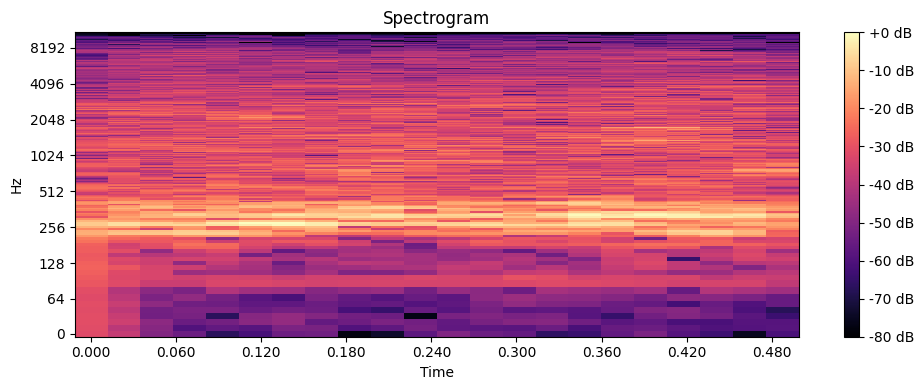

In [12]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [13]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

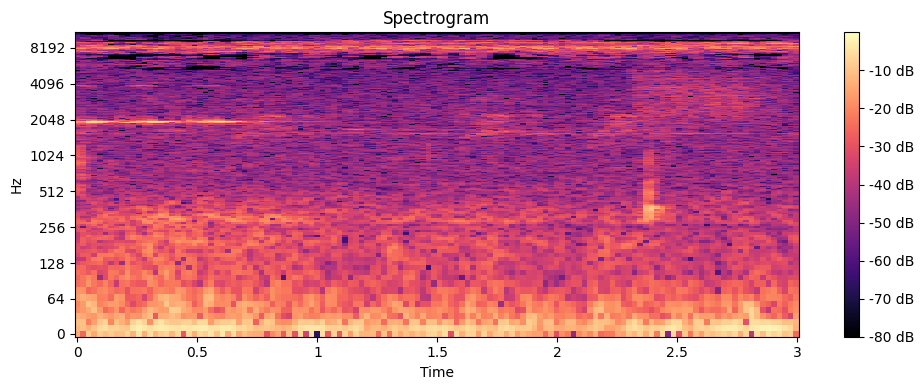

In [14]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [15]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

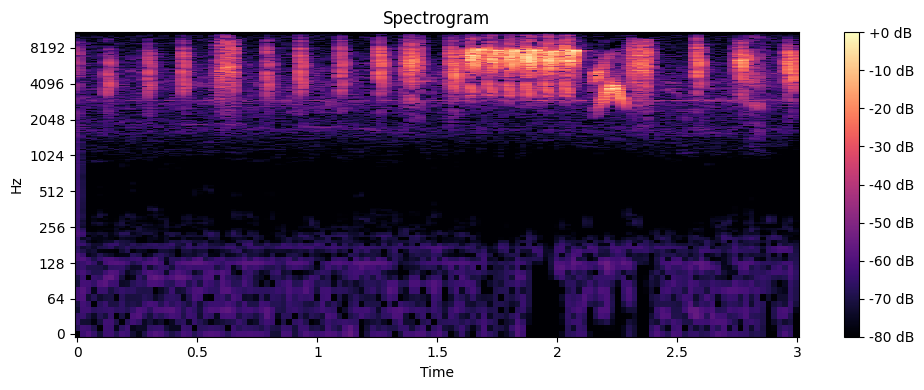

In [16]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [17]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

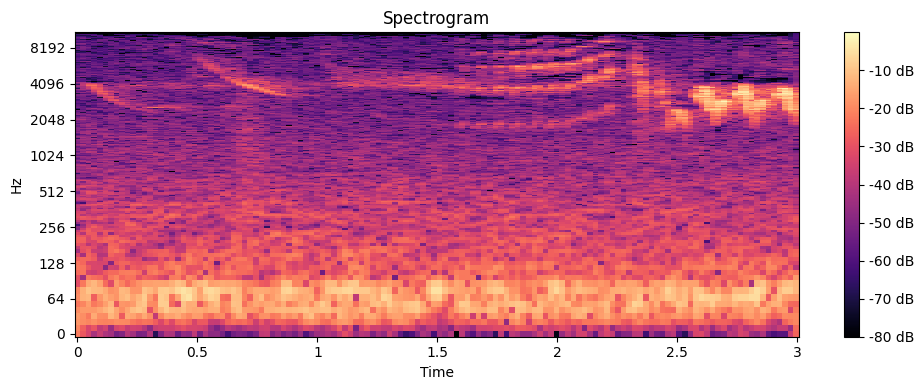

In [18]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [19]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")